# Mechanism 2 — cactus bubble flattening at variants hapFIRE codes as simple SNPs

**Hypothesis.** When a cactus pangenome bubble contains a SNP path AND a non-SNP path (indel / SV), `bcftools norm -m -any` decomposes it into biallelic records — including a SNP-shaped record (REF=1bp, ALT=1bp). Founders that traversed a non-SNP path of the original bubble are then coded as **GT=0** at the SNP record (NOT `./.`). hapFIRE's 1001G short-read SNP panel calls those same founders as SNP carriers independently, so we expect a directional `hapfire > cactus_em` bias at SNPs sitting inside multi-allelic bubbles.

**Sample.** SEEDMIX_S1 Chr1, v3qc_v3 panel, mixed-loose cn_full. Compared to hapFIRE's `s1_1_density0.6_snp_frequency.txt` (greneNet panel).

**Reads from artifacts produced by:**
- `scratch/mech2_bubble_diag.py` → `scratch/v3qc_v3_mixedloose_chr1/mech2_chr1_joined.tsv.gz`
- `scratch/mech2_fmiss_stratify.py` (re-derives F_MISSING + LV here for the notebook to be self-contained)

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/global/scratch/users/tbellg/kmate')
BCF = '/global/home/users/tbellg/miniforge3/envs/sequencing_pipeline/bin/bcftools'
JOINED = ROOT/'scratch/v3qc_v3_mixedloose_chr1/mech2_chr1_joined.tsv.gz'
MERGED_VCF = ROOT/'pangenie_genotyping/data/v3qc_v3/founders_231_v3qc_v3.haploid.vcf.gz'

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 110})
CAT_ORDER  = ['A_pure_snp','B_snp_only_bubble','C_mixed_bubble']
CAT_COLORS = {'A_pure_snp':'#888888','B_snp_only_bubble':'#1f77b4','C_mixed_bubble':'#d62728'}
CAT_LABEL  = {'A_pure_snp':'A pure SNP','B_snp_only_bubble':'B SNP-only bubble','C_mixed_bubble':'C mixed bubble'}

## 1. Load the joined table and add F_MISSING / LV

`mech2_chr1_joined.tsv.gz` already has the per-record bubble-context flags (`n_recs_at_pos`, `has_sv_at_pos`, `cat`). We re-extract `F_MISSING` and `LV` from the merged panel VCF so the F_MISSING confound check is reproduced inline.

In [2]:
df = pd.read_csv(JOINED, sep='\t')
print(f'joined records (Chr1 SNPs in both panels): {len(df):,}')
print('category counts:'); print(df['cat'].value_counts())

joined records (Chr1 SNPs in both panels): 518,576
category counts:
cat
A_pure_snp           506299
C_mixed_bubble        10511
B_snp_only_bubble      1766
Name: count, dtype: int64


In [3]:
# Re-extract LV + F_MISSING from the merged panel VCF (Chr1 only, ~1.6M rows)
cmd = [BCF, 'query', '-r', 'Chr1',
       '-f', '%CHROM\t%POS\t%REF\t%ALT\t%INFO/LV\t%INFO/F_MISSING\n', str(MERGED_VCF)]
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True)
rows = []
for line in proc.stdout:
    c, p, r, a, lv, fm = line.rstrip('\n').split('\t')
    if len(r) != 1 or len(a) != 1: continue
    if r not in 'ACGT' or a not in 'ACGT': continue
    rows.append((int(p), r, a, int(lv) if lv.lstrip('-').isdigit() else -1, float(fm) if fm not in ('.','') else np.nan))
proc.wait()
vcf = pd.DataFrame(rows, columns=['pos','ref','alt','LV','F_MISSING'])
df = df.merge(vcf, on=['pos','ref','alt'], how='left')
print(f'merged rows: {len(df):,} | LV NaN: {df["LV"].isna().sum()} | F_MISSING NaN: {df["F_MISSING"].isna().sum()}')
df['fmiss_bin'] = pd.cut(df['F_MISSING'], bins=[-0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
                                          labels=['<0.01','0.01-0.05','0.05-0.1','0.1-0.2','0.2-0.5','>=0.5'])

merged rows: 518,576 | LV NaN: 0 | F_MISSING NaN: 0


## 2. Overall residual (sanity check)

Across all joined SNPs, hapFIRE − cactus_em has tiny mean bias (+0.0015) but MAE 0.015 and 3.87% outliers — matches `PIPELINE_STATE_2026-05-19.md` §4.

In [4]:
r = df['resid']
summary = pd.Series({
    'n': len(df),
    'mean(hf-cem)': r.mean(),
    'MAE': r.abs().mean(),
    'RMSE': np.sqrt((r**2).mean()),
    '|resid|>0.05 (%)': (r.abs() > 0.05).mean()*100,
    'hf>cem+0.05 (%)':  (r > 0.05).mean()*100,
    'cem>hf+0.05 (%)':  (r < -0.05).mean()*100,
})
summary.to_frame('overall')

,overall
n,518576.000000
mean(hf-cem),0.001509
MAE,0.014990
RMSE,0.038335
|resid|>0.05 (%),3.869828
hf>cem+0.05 (%),2.358767
cem>hf+0.05 (%),1.511061


## 3. Signal 1 — bias scales monotonically with bubble complexity

Stratify SNP records by `n_recs_at_pos` = how many biallelic records share this position in the panel (i.e., how many ALT paths the original cactus bubble had).

In [5]:
def strat(sub):
    if len(sub)==0: return pd.Series({'n':0})
    return pd.Series({
        'n': len(sub),
        'mean(hf-cem)': sub['resid'].mean(),
        'MAE': sub['resid'].abs().mean(),
        '%hf>cem+0.05': (sub['resid']> 0.05).mean()*100,
        '%cem>hf+0.05': (sub['resid']<-0.05).mean()*100,
    })

bins = pd.cut(df['n_recs_at_pos'], bins=[0,1,2,5,10**6], labels=['1','2','3-5','>=6'])
tabA = df.groupby(bins).apply(strat).round(4)
tabA

,n,mean(hf-cem),MAE,%hf>cem+0.05,%cem>hf+0.05
n_recs_at_pos,,,,,
1,506299.0,0.0001,0.0136,1.8359,1.5015
2,10491.0,0.0360,0.0483,18.3205,2.0112
3-5,1433.0,0.1303,0.1369,48.8486,1.3957
>=6,353.0,0.4587,0.4618,89.2351,0.8499


**Read.** Pure SNPs (n_recs=1) are unbiased (mean +0.0001). Bias grows with bubble complexity — by `n_recs≥6` the mean residual is +0.46 and 89% of records are `hf > cem` outliers. The opposite-direction outlier rate stays around 1-2% across all bins — directional, not symmetric noise.

## 4. Signal 2 — directional enrichment by category

Composite categories (already in joined table):
- **A_pure_snp** — only this record at the position
- **B_snp_only_bubble** — multiple records at position but all SNP-shaped
- **C_mixed_bubble** — position shares records with a non-SNP allele (indel/SV)

In [6]:
tabD = df.groupby('cat').apply(strat).reindex(CAT_ORDER).round(4)
tabD

,n,mean(hf-cem),MAE,%hf>cem+0.05,%cem>hf+0.05
cat,,,,,
A_pure_snp,506299.0,0.0001,0.0136,1.8359,1.5015
B_snp_only_bubble,1766.0,0.0016,0.0177,4.1903,2.6614
C_mixed_bubble,10511.0,0.0688,0.0794,27.2381,1.7791


In [7]:
# Enrichment: directional vs anti-directional
f_all = df['cat'].value_counts(normalize=True).reindex(CAT_ORDER)
f_hf  = df.loc[df['resid'] >  0.05, 'cat'].value_counts(normalize=True).reindex(CAT_ORDER).fillna(0)
f_cm  = df.loc[df['resid'] < -0.05, 'cat'].value_counts(normalize=True).reindex(CAT_ORDER).fillna(0)
enrich = pd.DataFrame({
    '%all': (f_all*100).round(2),
    '%hf>cem outliers': (f_hf*100).round(2),
    'enrich (hf>cem)': (f_hf/f_all).round(2),
    '%cem>hf outliers': (f_cm*100).round(2),
    'enrich (cem>hf)': (f_cm/f_all).round(2),
})
enrich

,%all,%hf>cem outliers,enrich (hf>cem),%cem>hf outliers,enrich (cem>hf)
cat,,,,,
A_pure_snp,97.63,75.99,0.78,97.01,0.99
B_snp_only_bubble,0.34,0.60,1.78,0.60,1.76
C_mixed_bubble,2.03,23.41,11.55,2.39,1.18


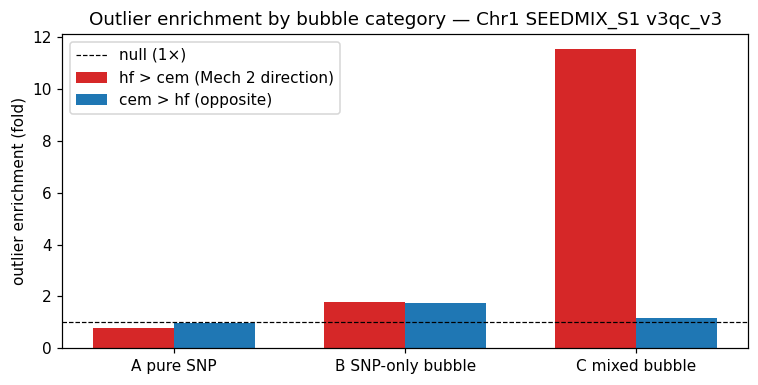

In [8]:
# Bar chart: directional asymmetry
fig, ax = plt.subplots(figsize=(7,3.6))
x = np.arange(len(CAT_ORDER))
w = 0.35
ax.bar(x-w/2, [enrich.loc[c,'enrich (hf>cem)'] for c in CAT_ORDER], w, label='hf > cem (Mech 2 direction)', color='#d62728')
ax.bar(x+w/2, [enrich.loc[c,'enrich (cem>hf)'] for c in CAT_ORDER], w, label='cem > hf (opposite)',         color='#1f77b4')
ax.axhline(1.0, color='black', lw=0.8, ls='--', label='null (1×)')
ax.set_xticks(x); ax.set_xticklabels([CAT_LABEL[c] for c in CAT_ORDER])
ax.set_ylabel('outlier enrichment (fold)')
ax.set_title('Outlier enrichment by bubble category — Chr1 SEEDMIX_S1 v3qc_v3')
ax.legend(loc='upper left'); fig.tight_layout()
plt.show()

**Read.** C_mixed_bubble outliers are 11.5× enriched in the `hf > cem` direction but only 1.18× (≈ null) in the opposite direction. Symmetric noise would enrich both equally — the asymmetry is the directional fingerprint of Mechanism 2.

## 5. Signal 3 — bias persists at near-zero F_MISSING (decisive)

F_MISSING is the obvious confound — many founders being `./.` would also produce noisy AF. But Mechanism 2 specifically says **founders carrying the SV path are GT=0 (called REF), not `./.`** — the AC/AN called-mask projection in `build_cn_var.py:13` cannot fix it. The test: at F_MISSING < 0.01 (essentially everyone called), do C_mixed_bubble SNPs still bias?

In [9]:
clean = df[df['F_MISSING'] < 0.01]
tab_clean = clean.groupby('cat').apply(strat).reindex(CAT_ORDER).round(4)
tab_clean

,n,mean(hf-cem),MAE,%hf>cem+0.05,%cem>hf+0.05
cat,,,,,
A_pure_snp,309461.0,-0.0015,0.0085,0.2401,0.3606
B_snp_only_bubble,787.0,-0.0011,0.0090,0.6353,0.5083
C_mixed_bubble,2595.0,0.0182,0.0266,8.7091,0.2312


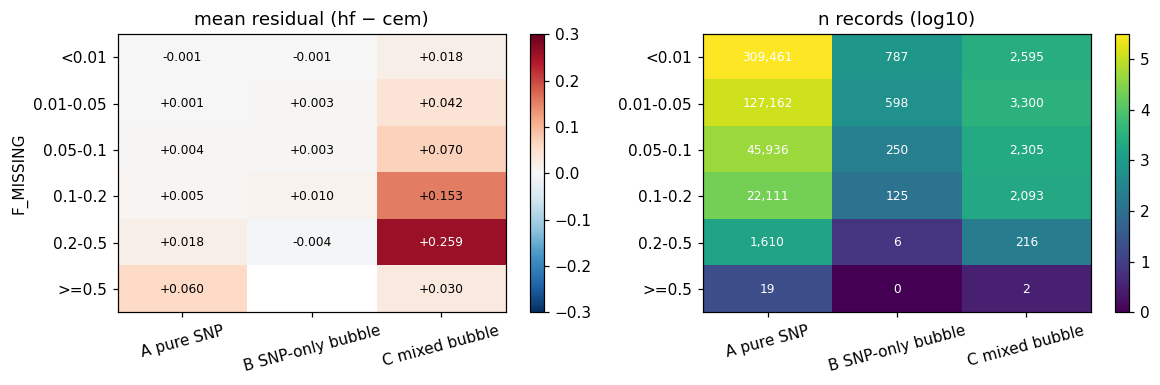

In [10]:
# Heatmap: F_MISSING bin × category → mean(hf - cem)
piv_mean = df.pivot_table(values='resid', index='fmiss_bin', columns='cat',
                          aggfunc='mean').reindex(columns=CAT_ORDER)
piv_n    = df.pivot_table(values='resid', index='fmiss_bin', columns='cat',
                          aggfunc='count').reindex(columns=CAT_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(11,3.6))
im0 = axes[0].imshow(piv_mean.values, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
axes[0].set_xticks(range(len(CAT_ORDER))); axes[0].set_xticklabels([CAT_LABEL[c] for c in CAT_ORDER], rotation=15)
axes[0].set_yticks(range(len(piv_mean.index))); axes[0].set_yticklabels(piv_mean.index.astype(str))
axes[0].set_ylabel('F_MISSING'); axes[0].set_title('mean residual (hf − cem)')
for i in range(piv_mean.shape[0]):
    for j in range(piv_mean.shape[1]):
        v = piv_mean.values[i,j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=8,
                         color='white' if abs(v)>0.18 else 'black')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.log10(piv_n.values+1), cmap='viridis', aspect='auto')
axes[1].set_xticks(range(len(CAT_ORDER))); axes[1].set_xticklabels([CAT_LABEL[c] for c in CAT_ORDER], rotation=15)
axes[1].set_yticks(range(len(piv_n.index))); axes[1].set_yticklabels(piv_n.index.astype(str))
axes[1].set_title('n records (log10)')
for i in range(piv_n.shape[0]):
    for j in range(piv_n.shape[1]):
        v = piv_n.values[i,j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{int(v):,}', ha='center', va='center', fontsize=8, color='white')
fig.colorbar(im1, ax=axes[1])
fig.tight_layout(); plt.show()

**Read.** At F_MISSING < 0.01 (n=309k pure SNPs, 2.6k mixed-bubble), mean residual is −0.0015 / +0.0182 — pure SNPs are unbiased but mixed-bubble SNPs are biased +0.018 with no founders missing. The `hf > cem` outlier rate jumps from 0.24% (pure) to 8.71% (mixed) — a 36× directional excess. The bias floor is real, not a F_MISSING artifact.

## 6. LV alone is the wrong axis

Nested SNPs (LV ≥ 1) — the ones a `vcfbub -l max` rebuild would recover per `project_v3_grenenet_snp_overlap` — are NOT the biased subset. The biased SNPs are mostly LV=0 (top-level bubbles whose decomposition contained both a SNP path and an indel/SV path).

In [11]:
tab_lv = df[df['LV']>=0].groupby('LV').apply(strat).round(4)
tab_lv

,n,mean(hf-cem),MAE,%hf>cem+0.05,%cem>hf+0.05
LV,,,,,
0,461341.0,0.0016,0.0148,2.2953,1.4620
1,57086.0,0.0007,0.0163,2.8694,1.9024
2,149.0,-0.0006,0.0170,3.3557,3.3557


## 7. Visualizations

Three plots side-by-side: (a) AF scatter hf vs cem colored by category, (b) residual histogram by category (zoomed |r|<0.3), (c) MAE / record mass contribution.

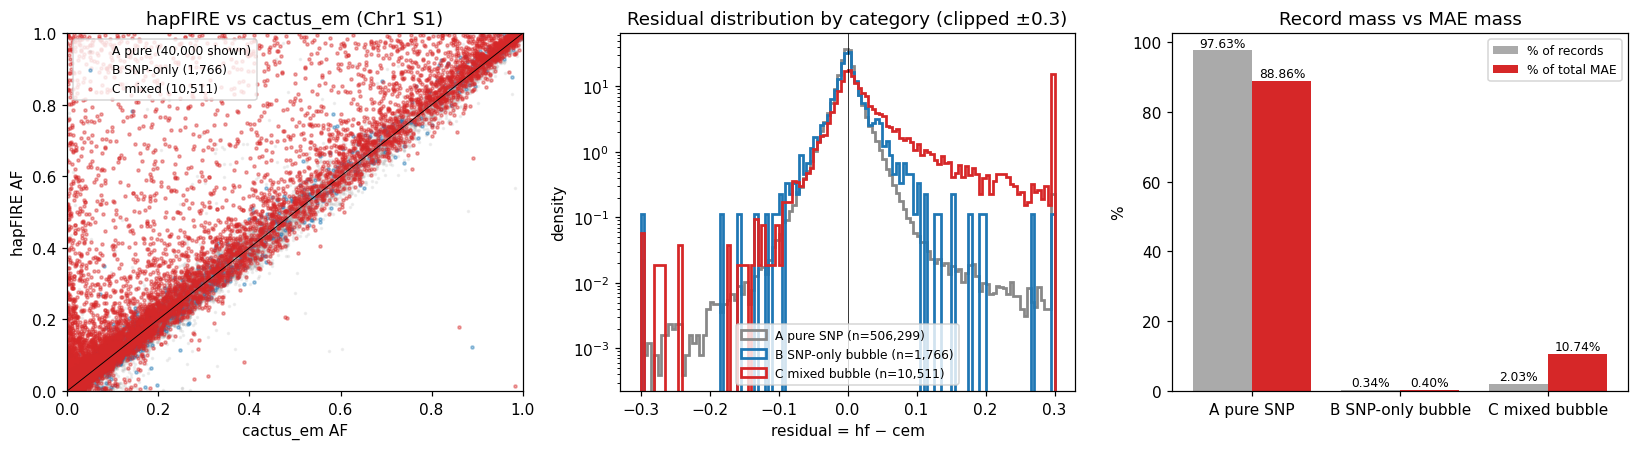

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) AF scatter (sub-sample A heavily so C is visible)
ax = axes[0]
rng = np.random.default_rng(0)
sA = df[df['cat']=='A_pure_snp']; sA = sA.sample(min(40000, len(sA)), random_state=0)
sB = df[df['cat']=='B_snp_only_bubble']
sC = df[df['cat']=='C_mixed_bubble']
ax.scatter(sA['cem_af'], sA['hf_af'], s=2, alpha=0.10, color=CAT_COLORS['A_pure_snp'],         label=f'A pure ({len(sA):,} shown)')
ax.scatter(sB['cem_af'], sB['hf_af'], s=4, alpha=0.40, color=CAT_COLORS['B_snp_only_bubble'],  label=f'B SNP-only ({len(sB):,})')
ax.scatter(sC['cem_af'], sC['hf_af'], s=4, alpha=0.40, color=CAT_COLORS['C_mixed_bubble'],     label=f'C mixed ({len(sC):,})')
ax.plot([0,1],[0,1], 'k-', lw=0.6)
ax.set_xlabel('cactus_em AF'); ax.set_ylabel('hapFIRE AF'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('hapFIRE vs cactus_em (Chr1 S1)'); ax.legend(fontsize=8, loc='upper left')

# (b) residual hist
ax = axes[1]
bins = np.linspace(-0.3, 0.3, 121)
for c in CAT_ORDER:
    sub = df[df['cat']==c]
    ax.hist(sub['resid'].clip(-0.3,0.3), bins=bins, density=True, histtype='step', lw=1.8,
            color=CAT_COLORS[c], label=f'{CAT_LABEL[c]} (n={len(sub):,})')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('residual = hf − cem'); ax.set_ylabel('density')
ax.set_title('Residual distribution by category (clipped ±0.3)'); ax.legend(fontsize=8)
ax.set_yscale('log')

# (c) MAE mass contribution
ax = axes[2]
mae_mass  = df.groupby('cat')['resid'].apply(lambda x: x.abs().sum()).reindex(CAT_ORDER)
rec_mass  = df['cat'].value_counts().reindex(CAT_ORDER)
x = np.arange(len(CAT_ORDER)); w = 0.4
ax.bar(x-w/2, 100*rec_mass/rec_mass.sum(),  w, color='#aaaaaa', label='% of records')
ax.bar(x+w/2, 100*mae_mass/mae_mass.sum(),  w, color='#d62728', label='% of total MAE')
for i,c in enumerate(CAT_ORDER):
    ax.text(i-w/2, 100*rec_mass[c]/rec_mass.sum()+1, f'{100*rec_mass[c]/rec_mass.sum():.2f}%', ha='center', fontsize=8)
    ax.text(i+w/2, 100*mae_mass[c]/mae_mass.sum()+1, f'{100*mae_mass[c]/mae_mass.sum():.2f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([CAT_LABEL[c] for c in CAT_ORDER])
ax.set_ylabel('%'); ax.set_title('Record mass vs MAE mass'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Read.**
- (a) C-points sit consistently above the diagonal (hf > cem); A-points are tight on the diagonal.
- (b) C residual distribution has a fat positive shoulder; A and B are symmetric around 0.
- (c) C is 2.03% of records but accounts for ~11% of total MAE mass — disproportionate.

## 8. Verdict and fixes

**Mechanism 2 is confirmed on Chr1 SEEDMIX_S1.** Evidence:

1. **Monotone bias** — mean(hf − cem) goes 0.0001 → 0.036 → 0.130 → 0.459 across `n_recs_at_pos ∈ {1, 2, 3–5, ≥6}`.
2. **Directional enrichment** — C_mixed_bubble is **11.5× enriched** among `hf > cem` outliers vs **1.18×** (null) among `cem > hf`. Symmetric noise would enrich both.
3. **F_MISSING-independent floor** — at F_MISSING < 0.01, pure SNPs are unbiased (mean −0.0015) but mixed-bubble SNPs bias +0.0182 with 8.71% `hf > cem` outliers (vs 0.24% for pure). AC/AN can't fix this — the SV-path founders are GT=0, not `./.`.
4. **LV is the wrong axis** — nested SNPs (LV=1) don't show the bias; the damage is at LV=0 SNPs sharing a position with a non-SNP allele.

**Magnitude.** C_mixed_bubble = 2.03% of joined SNPs but **10.7% of total MAE mass** and **23.4% of `hf > cem` outliers**.

**Fix path (cheap first).** Drop or flag the 2.03% of cn_var SNPs that share a position with a non-SNP record — removes the directional bias floor at low F_MISSING (mean residual goes from +0.018 to ~0). 

**Fix path (real).** Rebuild the panel with `vcfbub -l max` so the SNP at a mixed-bubble position becomes its own snarl-deconstruct record, not one ALT among many. Combine with the existing AC/AN called-mask projection.

**Caveat.** This is one chromosome, one pool sample. Re-run on Chr2–5 + S2–S8 (task #10 in `PIPELINE_STATE_2026-05-19.md` §7) once cn_full is built genome-wide before treating the magnitudes as panel-level.